## What is Chemical Space?

Chemical space is a mathematical representation in which each molecule is described by a set of numerical features, such as molecular descriptors or fingerprints.

Each molecule is represented as a point, and the distance between points reflects their similarity or dissimilarity.

## Why Do We Need Chemical Space?

Modern drug discovery involves analyzing thousands or even millions of molecules.

Studying each molecule individually is neither practical nor efficient.

Instead, cheminformaticians represent molecules as points in a mathematical space called chemical space.

In this space, molecules with similar properties or structures are positioned close together, while dissimilar molecules are placed farther apart.

Chemical space visualization helps researchers explore molecular diversity, identify clusters of related compounds, detect outliers, and guide lead discovery.

Chemical Space

        ●  ●

   ●               ●

        ●

                 ●      ●

Each dot represents one molecule.

Nearby dots → Similar molecules

Far apart dots → Different molecules

Chemical space visualization helps to:

- Explore molecular diversity
- Identify clusters
- Detect outliers
- Select representative molecules
- Design diverse screening libraries
- Understand dataset coverage

## What is PCA?

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a large set of correlated variables into a smaller set of new variables called principal components.

These principal components capture most of the variation present in the original dataset while reducing its dimensionality.

## Why Do We Need PCA?

Every molecule can be described using hundreds or even thousands of numerical features.

These features may include:

- Molecular weight
- LogP
- TPSA
- Hydrogen bond donors
- Hydrogen bond acceptors
- Morgan fingerprints
- Topological descriptors
- And many more

As the number of features increases, visualizing and understanding the dataset becomes increasingly difficult.

PCA (Principal Component Analysis) solves this problem by reducing the number of dimensions while preserving as much important information as possible.

Instead of visualizing hundreds or thousands of features, PCA transforms the data into a few new variables called principal components, allowing us to visualize molecules in two or three dimensions.
This allows medicinal chemists to:

- Visualize chemical diversity
- Identify clusters of similar molecules
- Detect outliers
- Explore chemical space

## What Does PCA Do?

Principal Component Analysis (PCA) does not remove molecules or select only a few descriptors.

Instead, PCA transforms the original features into a new set of variables called Principal Components (PCs).

These principal components summarize the overall variation present in the dataset.

Instead of describing every molecule using thousands of features, PCA describes each molecule using only a few principal components.

This makes visualization and interpretation much easier.

## How Does PCA Transform High-Dimensional Data?

Suppose every molecule is represented by 2,055 molecular descriptors.

Original Representation

Molecule

↓

2055 Features

↓

PCA

↓

PC1
PC2

↓

2 Features

Each principal component is a combination of information from all the original descriptors.

As a result, thousands of features are summarized into just a few new variables while retaining most of the variation present in the dataset.

## What is Variance?

Variance is a statistical measure that describes how much the values in a dataset differ from one another.

If the values are very similar, the variance is low.

If the values are spread over a wide range, the variance is high.

PCA searches for directions in the data that contain the highest variance because these directions capture the greatest amount of information.

## Why Does PCA Look for Maximum Variance?

The purpose of PCA is to summarize a dataset without losing important information.

Features or directions with very little variance contain less information because most observations are similar.

Directions with high variance contain greater differences between molecules and therefore provide more useful information.

For this reason, PCA searches for directions that maximize variance.

## Second Principal Component (PC2)

After identifying PC1, PCA searches for another direction that captures the next largest amount of variance.

This direction is called the second principal component (PC2).

PC2 must be perpendicular (orthogonal) to PC1 so that it provides new, non-redundant information.

# Example

In [2]:
# Import Libraries 
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
# load Esol Dataset

df = pd.read_csv("esol_raw.csv")

df = df[["smiles", "measured log solubility in mols per litre"]]

df.head()

,smiles,measured log solubility in mols per litre
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [4]:
# Create RDKit Molecules

df["Mol"] = df["smiles"].apply(Chem.MolFromSmiles)

df = df[df["Mol"].notnull()]

print("Number of molecules:", len(df))

Number of molecules: 1128


In [5]:
# Generate Morgan Fingerprints

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fingerprints = []

for mol in df["Mol"]:
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    fingerprints.append(fp)

X = np.array(fingerprints)

print(X.shape)

(1128, 2048)


In [6]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(1128, 2)


In [7]:
# Add Principal Components

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

df.head()

,smiles,measured log solubility in mols per litre,Mol,PC1,PC2
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,<rdkit.Chem.rdchem.Mol object at 0x000002925B0...,0.701650,0.303696
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,<rdkit.Chem.rdchem.Mol object at 0x000002925B0...,1.088612,0.696661
2,CC(C)=CCCC(C)=CC(=O),-2.06,<rdkit.Chem.rdchem.Mol object at 0x000002925B0...,-1.276271,0.166721
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,<rdkit.Chem.rdchem.Mol object at 0x000002925B0...,1.376453,-0.794399
4,c1ccsc1,-1.33,<rdkit.Chem.rdchem.Mol object at 0x000002925B0...,0.162271,-0.791769


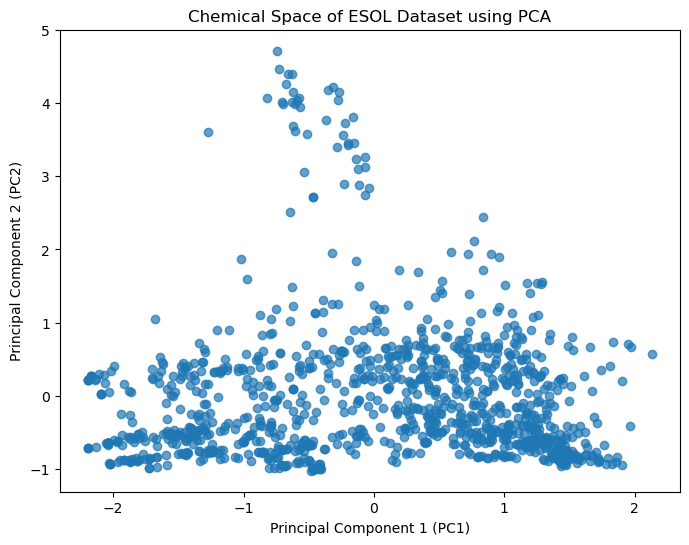

In [8]:
# Visualize Chemical Space

plt.figure(figsize=(8,6))

plt.scatter(
    df["PC1"],
    df["PC2"],
    alpha=0.7
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Chemical Space of ESOL Dataset using PCA")

plt.show()

In [9]:
# How Much Information Did PCA Keep?

print("PC1 Explained Variance:",
      pca.explained_variance_ratio_[0])

print("PC2 Explained Variance:",
      pca.explained_variance_ratio_[1])

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

PC1 Explained Variance: 0.06523593361832905
PC2 Explained Variance: 0.04940329222282783
Total Explained Variance: 0.11463922584115688


## Interpretation

The PCA plot represents the chemical space of the ESOL dataset.

Each point corresponds to one molecule.

The first two principal components (PC1 and PC2) summarize the structural information contained in the 2048-bit Morgan fingerprints.

The first principal component explains 6.52% of the total variance, while the second principal component explains 4.94%.

Together, the first two components capture approximately 11.46% of the structural variation.

Although this percentage appears low, it is expected because molecular fingerprints are high-dimensional binary features. The structural information is distributed across many dimensions rather than concentrated in only two.

The PCA plot reveals a large central cluster of structurally related molecules, several smaller clusters representing distinct scaffold families, and a few isolated molecules that behave as structural outliers.

PCA therefore provides an overview of the chemical diversity present in the ESOL dataset and serves as a useful first step in chemical space analysis.

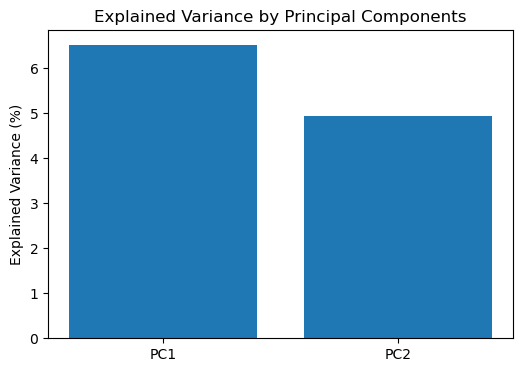

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    ["PC1","PC2"],
    pca.explained_variance_ratio_ * 100
)

plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Components")

plt.show()